In [1]:
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Prepocessing and modeling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, accuracy_score, roc_auc_score


#Handling imbalance
from imblearn.over_sampling import SMOTE

In [3]:
# Load the dataset
dataset = pd.read_excel('/content/AML Dataset.xlsx')

#Overview
print("Dataset Shape:", dataset.shape)
dataset.head()

Dataset Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,9.125000e+01,3.146400e+09,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-2.490900e+09,3.113600e+09,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-2.477800e+09,3.097200e+09,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,2.286000e+09,3.048100e+09,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,1.342100e+09,2.982500e+02,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [4]:
# Check the structure and data types of the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180519 non-null  object        
 1   Days for shipping (real)       180519 non-null  int64         
 2   Days for shipment (scheduled)  180519 non-null  int64         
 3   Benefit per order              180519 non-null  float64       
 4   Sales per customer             180519 non-null  float64       
 5   Delivery Status                180519 non-null  object        
 6   Late_delivery_risk             180519 non-null  int64         
 7   Category Id                    180519 non-null  int64         
 8   Category Name                  180519 non-null  object        
 9   Customer City                  180519 non-null  object        
 10  Customer Country               180519 non-null  object        
 11  

In [5]:
# Descriptive statistics for numerical features
dataset.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status,shipping date (DateOrders)
count,180519.000000,180519.000000,1.805190e+05,1.805190e+05,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,1.805190e+05,...,1.805190e+05,1.805190e+05,1.805190e+05,24840.000000,180519.000000,180519.000000,0.0,1.805190e+05,180519.0,180519
mean,3.497654,2.931847,2.296822e+09,2.225808e+09,0.548291,31.851451,6691.379495,35921.126914,5.443460,2.676434e+09,...,2.167559e+09,2.225808e+09,2.296822e+09,55426.132327,692.509764,31.851451,NaN,3.021983e+09,0.0,2016-06-16 05:45:23.202433024
min,0.000000,0.000000,-9.999000e+09,1.050000e+01,0.000000,2.000000,1.000000,603.000000,2.000000,-3.393755e+09,...,2.200000e+01,1.050000e+01,-9.999000e+09,1040.000000,19.000000,2.000000,NaN,2.200000e+01,0.0,2015-01-03 00:00:00
25%,2.000000,2.000000,6.375000e+01,3.839800e+08,0.000000,18.000000,3258.500000,725.000000,4.000000,1.824162e+09,...,3.999800e+08,3.839800e+08,6.375000e+01,23464.000000,403.000000,18.000000,NaN,3.999800e+08,0.0,2015-09-25 06:59:00
50%,3.000000,4.000000,1.945000e+09,1.599900e+09,1.000000,29.000000,6457.000000,19380.000000,5.000000,2.980869e+09,...,1.499400e+09,1.599900e+09,1.945000e+09,59405.000000,627.000000,29.000000,NaN,1.999900e+09,0.0,2016-06-15 08:32:00
75%,5.000000,4.000000,4.948500e+09,2.549800e+09,1.000000,45.000000,9779.000000,78207.000000,7.000000,3.841570e+09,...,2.499000e+09,2.549800e+09,4.948500e+09,90008.000000,1004.000000,45.000000,NaN,4.998000e+09,0.0,2017-03-04 21:29:00
max,6.000000,4.000000,9.999000e+09,9.999000e+09,1.000000,76.000000,20757.000000,99205.000000,12.000000,4.878193e+09,...,9.999900e+09,9.999000e+09,9.999000e+09,99301.000000,1363.000000,76.000000,NaN,9.999900e+09,0.0,2018-02-06 22:14:00
std,1.623722,1.374449,3.855228e+09,2.384095e+09,0.497664,15.640064,4162.918106,37542.461122,1.629246,1.254631e+09,...,2.398984e+09,2.384095e+09,3.855228e+09,31919.279101,336.446807,15.640064,NaN,2.901719e+09,0.0,NaN


In [6]:
# Checking the missing values
print("Missing Values:\n", dataset.isnull().sum())

Missing Values:
 Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                 

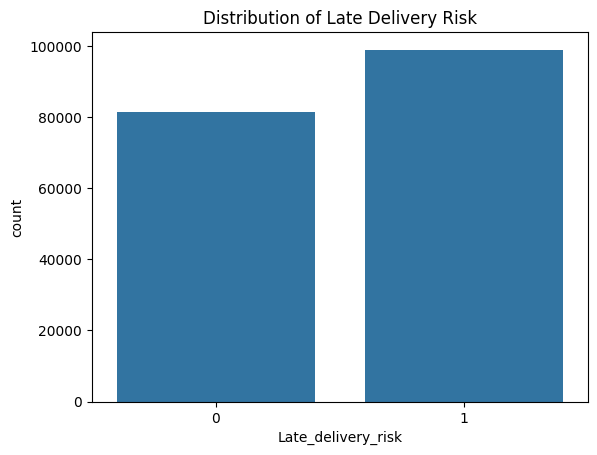

In [7]:
# Distribution of the target variable (Late Delivery Risk)
sns.countplot(x='Late_delivery_risk', data=dataset)
plt.title('Distribution of Late Delivery Risk')
plt.show()

In [8]:
#Feature Engineering
#1. Shipping delay (actual-scheduled)
if'Days for shipping (real)' in dataset.columns and 'Days for shipment (scheduled)' in dataset.columns: dataset['Shipping_delay'] = dataset['Days for shipping (real)'] - dataset['Days for shipment (scheduled)']

#2. Expedited shipping flag
if 'Shipping Mode' in dataset.columns: dataset['is_expedited'] = dataset['Shipping Mode'].apply(lambda x: 1 if 'First Class' in str(x) or 'Same Day' in str (x) else 0)


In [9]:
#Data Cleaning
dataset = dataset.drop(columns=["Product Image", "Product Description", "Order Zipcode", "shipping date (DateOrders)"])
dataset = dataset.drop(columns=[col for col in dataset.select_dtypes(include='object') if dataset[col].nunique() > 50], errors='ignore')
dataset = pd.get_dummies(dataset, drop_first=True)
dataset = dataset.dropna()

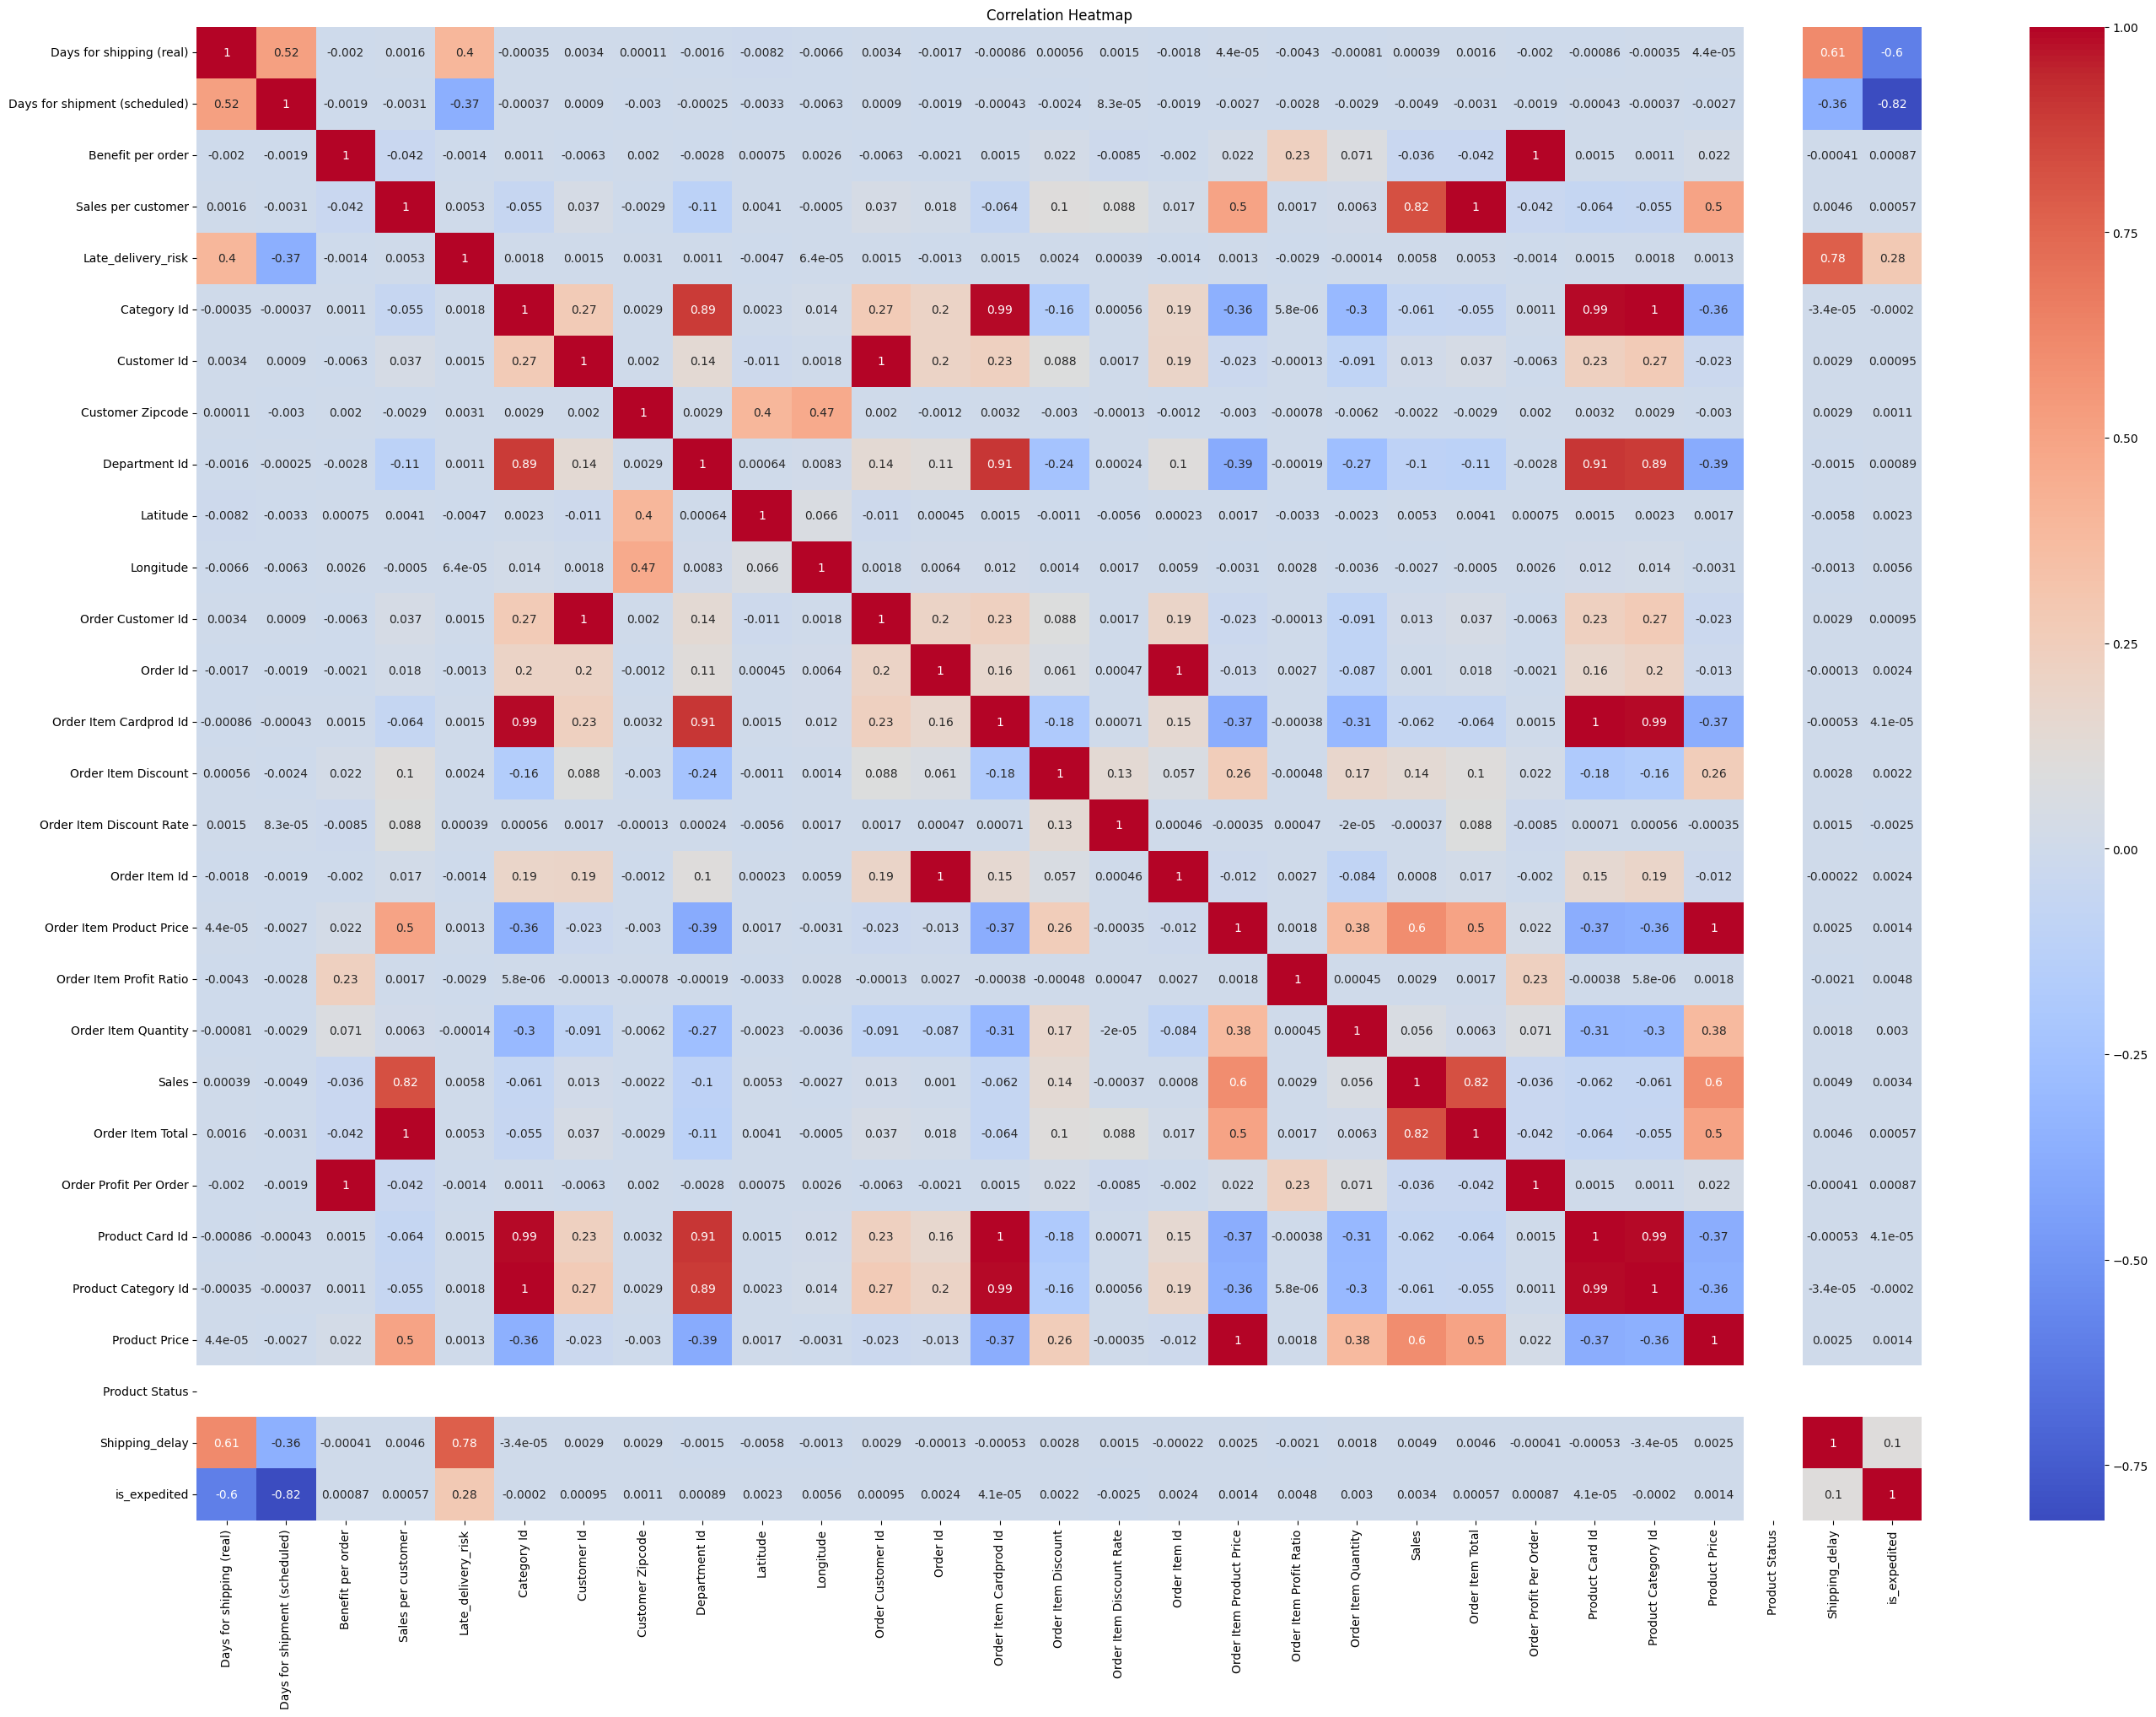

In [10]:
#Correlation Matrix
correlation_matrix = dataset.select_dtypes(include=np.number).corr()

plt.figure(figsize=(33, 23))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
# Remove highly correlated features (correlation > 0.9)
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs() > 0.9)]
dataset = dataset.drop(columns=to_drop)

In [12]:
# Display the remaining columns after dropping
print("Columns after dropping uncorrelated features:")
print(dataset.columns)

Columns after dropping uncorrelated features:
Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id',
       'Latitude',
       ...
       'Order Status_COMPLETE', 'Order Status_ON_HOLD',
       'Order Status_PAYMENT_REVIEW', 'Order Status_PENDING',
       'Order Status_PENDING_PAYMENT', 'Order Status_PROCESSING',
       'Order Status_SUSPECTED_FRAUD', 'Shipping Mode_Same Day',
       'Shipping Mode_Second Class', 'Shipping Mode_Standard Class'],
      dtype='object', length=172)


In [13]:
# Define features (X) and target variable (y)
X = dataset.drop(columns=['Late_delivery_risk'])  #Features
y = dataset['Late_delivery_risk']  #Target variable

#Feature Scaling
X = X.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")


Training set size: (144412, 20), Test set size: (36104, 20)


In [15]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Display the new class distribution after SMOTE
print("Class distribution after SMOTE:", np.bincount(y_train_res))

Class distribution after SMOTE: [79180 79180]


For Model Using Random Forest

In [16]:
# Define the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for Grid Search
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

# Perform Grid Search with 5-fold cross-validation
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, verbose=2, n_jobs=-1)
grid_search_rf.fit(X_train_res, y_train_res)

# Best parameters from Grid Search
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")

# Evaluate the model on the test set
y_pred_rf = grid_search_rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(classification_report(y_test, y_pred_rf))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Accuracy: 0.9754320850875249
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     16308
           1       0.96      1.00      0.98     19796

    accuracy                           0.98     36104
   macro avg       0.98      0.97      0.98     36104
weighted avg       0.98      0.98      0.98     36104



For Model Using GBM

In [17]:
# Define the Gradient Boosting Classifier (GBM)
gbm_model = GradientBoostingClassifier(random_state=42)

# Define the parameter grid for Grid Search
param_grid_gbm = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# Perform Grid Search with 5-fold cross-validation
grid_search_gbm = GridSearchCV(estimator=gbm_model, param_grid=param_grid_gbm, cv=5, verbose=2, n_jobs=-1)
grid_search_gbm.fit(X_train_res, y_train_res)

# Best parameters from Grid Search
print(f"Best parameters for Gradient Boosting: {grid_search_gbm.best_params_}")

# Evaluate the model on the test set
y_pred_gbm = grid_search_gbm.predict(X_test)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gbm)}")
print(classification_report(y_test, y_pred_gbm))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Gradient Boosting Accuracy: 0.975570573897629
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     16308
           1       0.96      1.00      0.98     19796

    accuracy                           0.98     36104
   macro avg       0.98      0.97      0.98     36104
weighted avg       0.98      0.98      0.98     36104



For model using ANN (using Keras)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4949/4949 - 8s - 2ms/step - accuracy: 0.9644 - loss: 0.1326 - val_accuracy: 0.9754 - val_loss: 0.1027
Epoch 2/20
4949/4949 - 10s - 2ms/step - accuracy: 0.9739 - loss: 0.1060 - val_accuracy: 0.9754 - val_loss: 0.1024
Epoch 3/20
4949/4949 - 8s - 2ms/step - accuracy: 0.9740 - loss: 0.1047 - val_accuracy: 0.9754 - val_loss: 0.1028
Epoch 4/20
4949/4949 - 10s - 2ms/step - accuracy: 0.9741 - loss: 0.1039 - val_accuracy: 0.9754 - val_loss: 0.1020
Epoch 5/20
4949/4949 - 10s - 2ms/step - accuracy: 0.9741 - loss: 0.1036 - val_accuracy: 0.9754 - val_loss: 0.1025
Epoch 6/20
4949/4949 - 7s - 1ms/step - accuracy: 0.9742 - loss: 0.1030 - val_accuracy: 0.9754 - val_loss: 0.1024
Epoch 7/20
4949/4949 - 10s - 2ms/step - accuracy: 0.9742 - loss: 0.1028 - val_accuracy: 0.9754 - val_loss: 0.1017
Epoch 8/20
4949/4949 - 10s - 2ms/step - accuracy: 0.9742 - loss: 0.1027 - val_accuracy: 0.9754 - val_loss: 0.1017
Epoch 9/20
4949/4949 - 10s - 2ms/step - accuracy: 0.9742 - loss: 0.1026 - val_accuracy: 0.9

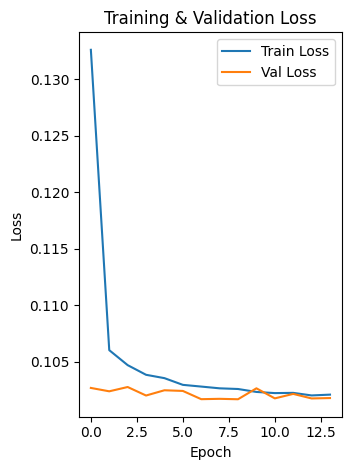

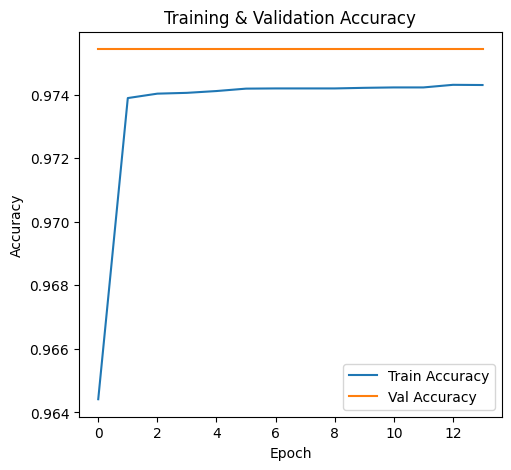

In [19]:
# Define the ANN model using Keras
ann_model = Sequential()
ann_model.add(Dense(units=64, activation='relu', input_dim=X_train_res.shape[1]))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(units=32, activation='relu'))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(units=1, activation='sigmoid'))  # Output layer for binary classification
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with 5-fold cross-validation
history = ann_model.fit(
    X_train_res, y_train_res,epochs=20, batch_size=32,
    validation_data=(X_test, y_test), callbacks=[early_stop],
    verbose=2
)

# Evaluate the model on the test set
y_pred_ann = (ann_model.predict(X_test) > 0.5).astype("int32")
print(f"ANN Accuracy: {accuracy_score(y_test, y_pred_ann)}")
print(classification_report(y_test, y_pred_ann))

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step


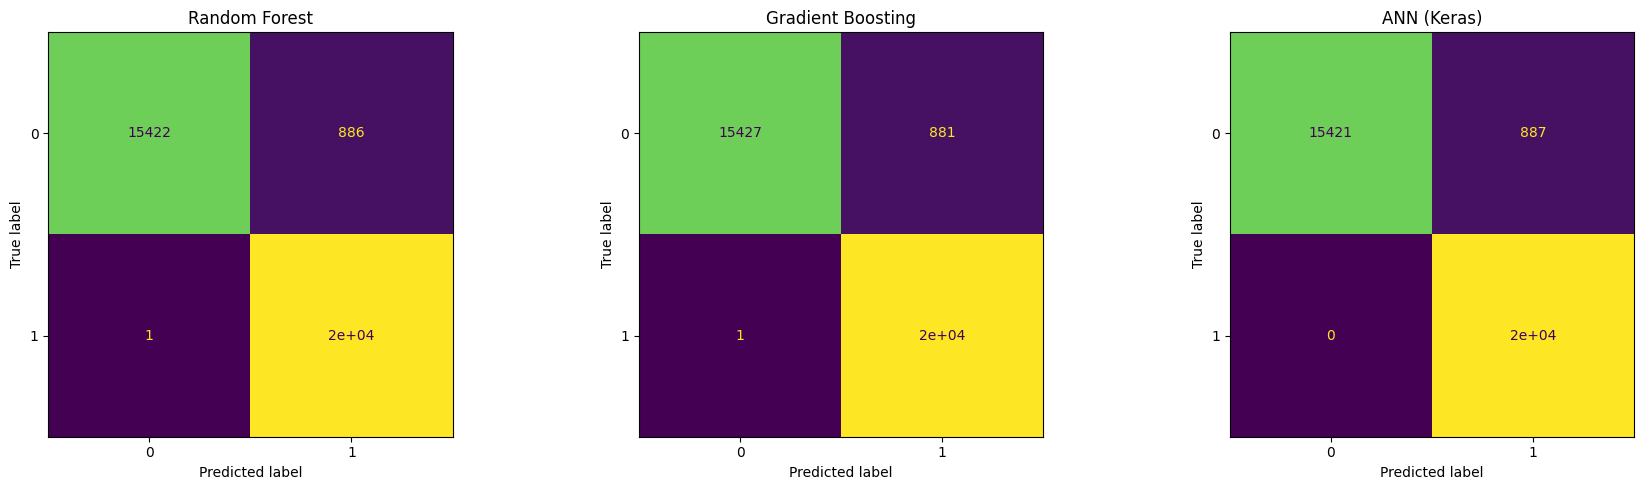

In [20]:
y_pred_rf = grid_search_rf.predict(X_test)
y_pred_gbm = grid_search_gbm.predict(X_test)
y_pred_ann = (ann_model.predict(X_test) > 0.5).astype("int32").flatten()

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RF
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0], colorbar=False)
axes[0].title.set_text("Random Forest")

# GBM
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gbm, ax=axes[1], colorbar=False)
axes[1].title.set_text("Gradient Boosting")

# ANN
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ann, ax=axes[2], colorbar=False)
axes[2].title.set_text("ANN (Keras)")

plt.tight_layout()
plt.show()

In [21]:
y_proba_rf = grid_search_rf.predict_proba(X_test)[:, 1]
y_proba_gbm = grid_search_gbm.predict_proba(X_test)[:, 1]
y_proba_ann = ann_model.predict(X_test).flatten()

# Metrics
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "ANN (Keras)"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gbm),
        accuracy_score(y_test, y_pred_ann)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_gbm),
        roc_auc_score(y_test, y_proba_ann)
    ]
}).sort_values(by="ROC AUC", ascending=False)

print("Model Performance Comparison:")
display(comparison_df)

1129/1129 ━━━━━━━━━━━━━━━━━━━━ 1s 704us/step
Model Performance Comparison:


,Model,Accuracy,ROC AUC
0,Random Forest,0.975432,0.989389
1,Gradient Boosting,0.975571,0.982192
2,ANN (Keras),0.975432,0.973554


In [23]:
print(type(shap_values_sample))
print(np.shape(shap_values_sample))

<class 'numpy.ndarray'>
(1000, 20, 2)


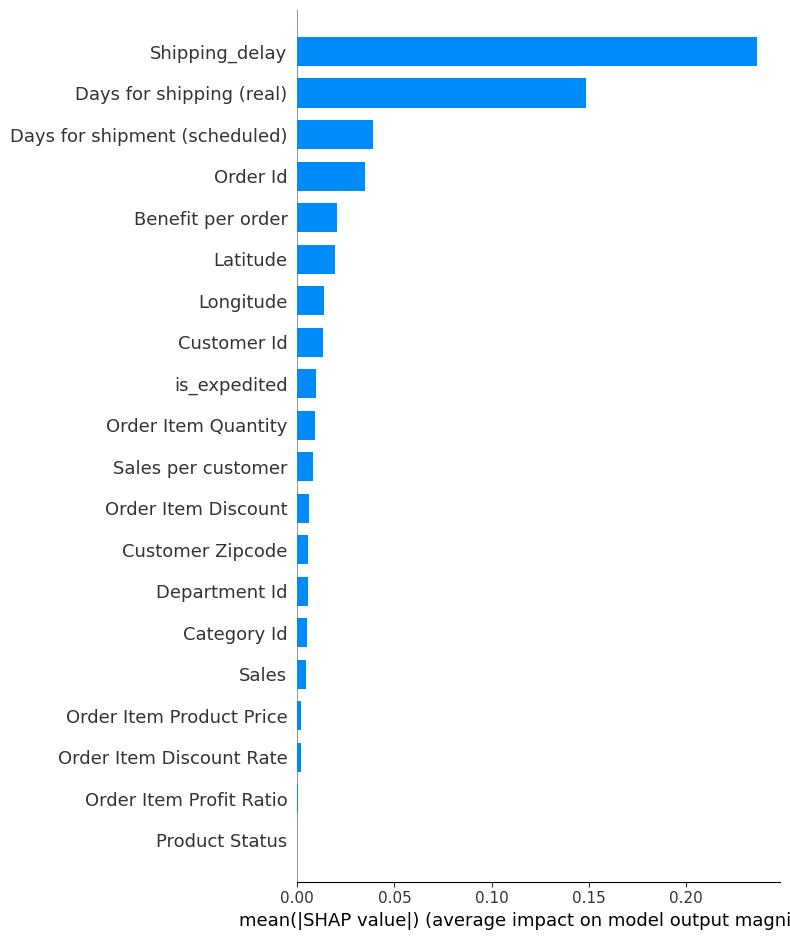

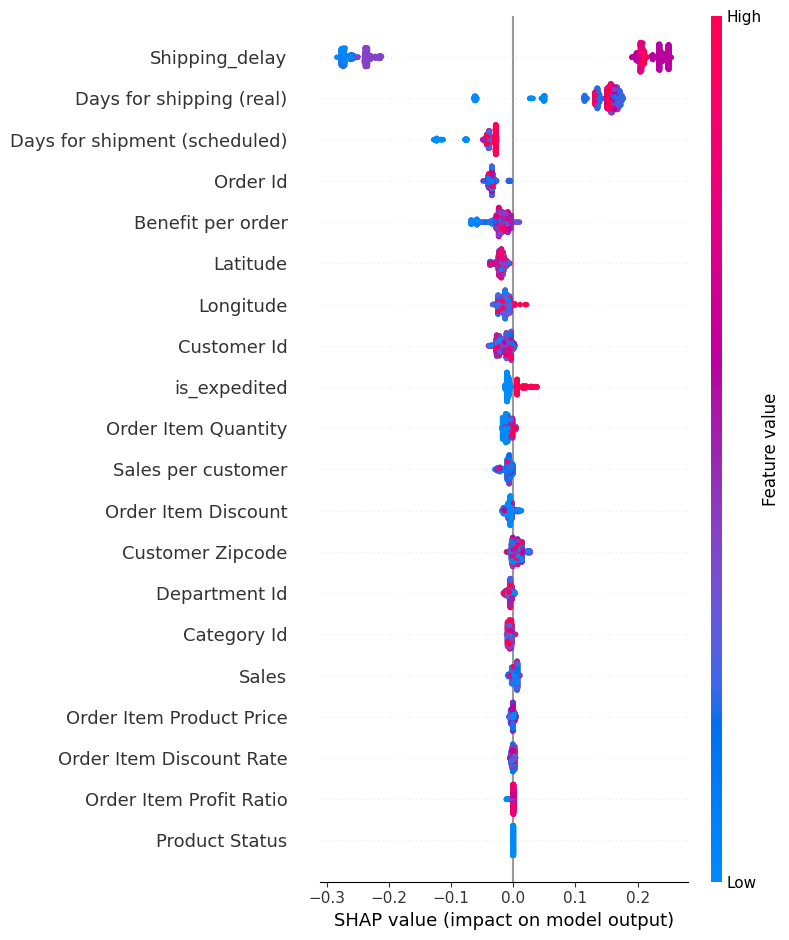

In [24]:
#Importance Features using SHAP
import shap
X_sample = X.sample(n=1000, random_state=42)
explainer = shap.TreeExplainer(grid_search_rf.best_estimator_)
shap_values_sample = explainer.shap_values(X_sample)
shap_to_plot = shap_values_sample[:, :, 1]
shap.summary_plot(shap_to_plot, X_sample, plot_type="bar")
shap.summary_plot(shap_to_plot, X_sample)